# Source A — Replacing the Cut Embedding With Typed Extraction

**Decision on the table:** Source A ships one number per county (article length)
after its 1,024-dimension `bge-m3` embedding was cut on cost. Can cheap, readable
features do better?

**Answer:** yes — 29 typed columns reach **2.7×** the mean cross-pillar lift of
article length, and exceed the cut embedding's, with no model download. The
advantage is concentrated on a handful of targets rather than uniform, and this
notebook says so where it matters.

Every number below is recomputed from `data/*.parquet` and `outputs/*.csv`
written by the pipeline scripts, not transcribed.

In [1]:
import json
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
DATA, ANALYSIS, OUTPUTS = REPO / "data", REPO / "analysis-output", REPO / "outputs"

mpl.rcParams.update({
    "figure.figsize": (11, 5.5), "figure.dpi": 110, "font.size": 13,
    "axes.titlesize": 16, "axes.titleweight": "bold", "axes.labelsize": 13,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
INK, ACCENT, MUTED, GOOD = "#1f2a37", "#c2410c", "#9ca3af", "#15803d"

features = pd.read_parquet(DATA / "source_a_text_features.parquet")
sections = pd.read_parquet(DATA / "source_a_sections.parquet")
rep = pd.read_csv(OUTPUTS / "source_a_representation.csv")
rep_tier = pd.read_csv(OUTPUTS / "source_a_representation_by_tier.csv")
stats = json.loads((ANALYSIS / "source-a" / "source_a_representation_stats.json").read_text())
sec_stats = json.loads((ANALYSIS / "source-a" / "source_a_section_stats.json").read_text())

print(f"{len(features):,} counties x {features.shape[1]} columns")
print(f"{len(sections):,} article sections across {sections.fips_code.nunique():,} counties")
print(f"{stats['n_targets']} scoring targets, {stats['n_folds']} folds, seed {stats['random_seed']}")

3,144 counties x 35 columns
64,588 article sections across 3,144 counties
28 scoring targets, 5 folds, seed 42


---

## 1. Where Source A stood

> **In plain terms:** each county's Wikipedia intro was converted into a list of
> 1,024 numbers, so counties described in similar words came out numerically
> similar. That step was removed — it needed a 2.2GB model and hours of CPU time,
> and barely beat simply counting the characters in the article.

The cut was made on **cost, not absence of signal**. The embedding did beat
`content_length`, just not by enough to justify itself. Source A was left
shipping one scalar, and this round asks what else that text can give up cheaply.

## 2. The corpus is extremely uneven — and the unevenness is economic

> **In plain terms:** some county articles are two sentences of population
> figures; others describe industries, universities, and rivers. Sorting counties
> by how much distinctive text they carry shows *what* the richer ones have more
> of.

This is the finding the whole round is built on. Counties are split into four
content tiers, then their articles are scanned for what kinds of facts appear.

In [2]:
import sys
sys.path.insert(0, str(REPO / "scripts"))
from analyze_source_a_tiers import assign_tiers

features["tier"] = assign_tiers(features["content_length"])
TIERS = ["stub", "thin", "mid", "rich"]

summary = features.groupby("tier", observed=True).agg(
    counties=("fips_code", "size"),
    min_chars=("content_length", "min"),
    max_chars=("content_length", "max"),
    any_industry=("n_industry_mentions", lambda s: (s > 0).mean()),
    proper_nouns=("n_distinct_proper_nouns", "mean"),
    metro=("has_metro_attachment", "mean"),
    namesake=("has_namesake", "mean"),
).loc[TIERS]

display(summary.style.format({
    "any_industry": "{:.1%}", "metro": "{:.1%}", "namesake": "{:.1%}",
    "proper_nouns": "{:.1f}",
}).set_caption("Content tiers: what each group's articles actually contain"))

,counties,min_chars,max_chars,any_industry,proper_nouns,metro,namesake
tier,,,,,,,
stub,294,33,99,0.7%,1.8,13.6%,6.8%
thin,1274,100,283,1.1%,5.2,43.6%,42.5%
mid,788,284,461,5.5%,8.7,61.2%,53.6%
rich,788,462,4403,25.3%,17.8,66.6%,51.6%


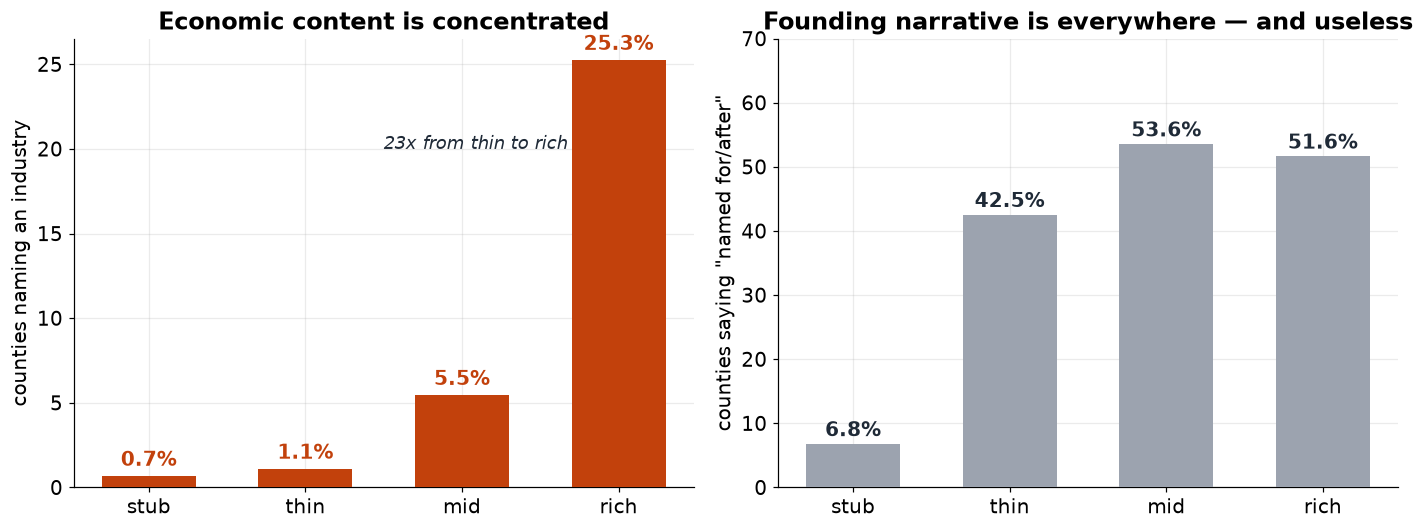

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(len(TIERS))

ax1.bar(x, summary["any_industry"] * 100, color=ACCENT, width=0.6, zorder=3)
for i, v in enumerate(summary["any_industry"] * 100):
    ax1.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontweight="bold", color=ACCENT)
ax1.set_xticks(x); ax1.set_xticklabels(TIERS)
ax1.set_ylabel("counties naming an industry")
ax1.set_title("Economic content is concentrated")
ax1.annotate("23x from thin to rich", xy=(1.5, 20), fontsize=12, style="italic", color=INK)

ax2.bar(x, summary["namesake"] * 100, color=MUTED, width=0.6, zorder=3)
for i, v in enumerate(summary["namesake"] * 100):
    ax2.text(i, v + 1.2, f"{v:.1f}%", ha="center", fontweight="bold", color=INK)
ax2.set_xticks(x); ax2.set_xticklabels(TIERS)
ax2.set_ylabel('counties saying "named for/after"')
ax2.set_title("Founding narrative is everywhere — and useless")
ax2.set_ylim(0, 70)
plt.tight_layout(); plt.show()

**Two readings decide the design.**

**Left:** only 6.5% of counties name an industry at all, and it is 23× more common
in the rich tier than the thin one. A dense embedding averaged over all 3,144
articles is dominated by counties with nothing economic to say. That is precisely
why it underperformed.

**Right:** the founding/namesake axis is flat across thin, mid, and rich. It has
mass everywhere and therefore separates nothing — which is exactly what the
earlier PCA analysis found its leading component to be (§3.2 of the findings, a
Texas-concentrated editorial artifact).

**A correction worth recording.** A first pass at this table reported the industry
gradient as 9.4% → 43.1%. That was wrong in both directions: the patterns were
case-sensitive and lacked word boundaries, so `port` matched "important",
"airport", and "transport". The corrected figures are steeper in gradient and much
lower in level.

## 3. What replaced the embedding

> **In plain terms:** instead of turning articles into abstract numbers, read
> specific facts out of them. Does this county mention mining? A university? A
> river? Being part of a metro area?

Every county gets the **same checklist**. A stub county answers "no" to nearly
everything — and that emptiness is informative, so nothing special has to happen
for it. One schema, no branching, no "not applicable" category to explain at the
feature-store handoff.

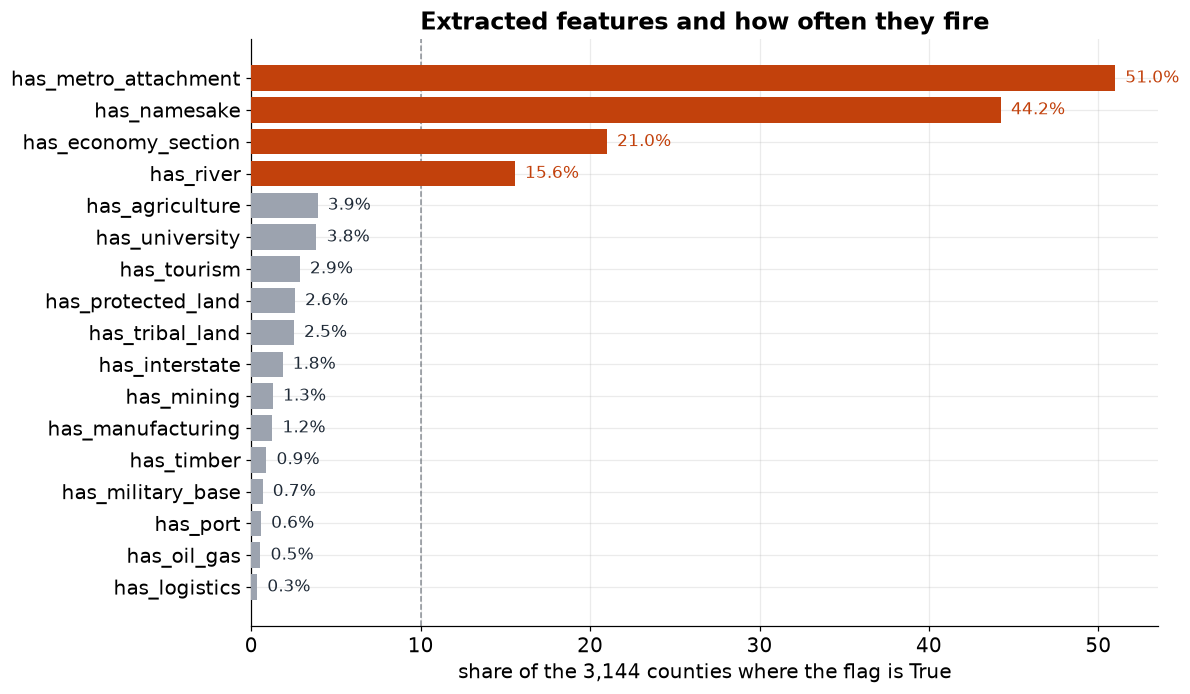

In [4]:
flags = [c for c in features.columns if c.startswith("has_") and c != "has_usda_echo"]
rates = (features[flags].mean() * 100).sort_values()

fig, ax = plt.subplots(figsize=(11, 6.5))
colors = [ACCENT if r >= 10 else MUTED for r in rates]
ax.barh(rates.index, rates.values, color=colors, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(v + 0.6, i, f"{v:.1f}%", va="center", fontsize=11,
            color=ACCENT if v >= 10 else INK)
ax.set_xlabel("share of the 3,144 counties where the flag is True")
ax.set_title("Extracted features and how often they fire")
ax.axvline(10, color=INK, lw=1, ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

Most flags are sparse. Only metro attachment, namesake, and river reach double
digits — the rest fire on a few percent of counties. That sparsity is the point,
but it also predicts what happens later: gains will be concentrated, not uniform.

### Precision had to be checked, and two flags failed

`has_military_base` originally matched `Fort [A-Z]` and the bare word `Army`.
Sampling its hits showed five of six were false: **Fort Wayne** and **Fort Yates**
are city names, **Fort Lemhi** an 1855 Mormon settlement, and `Army` catches Civil
War prose. `has_tribal_land` matched bare `Indian`, picking up "American Indian
Wars" and reservations dissolved in the 1830s.

Both were tightened to require an installation or present-tense land term.

In [5]:
precision_fix = pd.DataFrame([
    {"flag": "has_military_base", "before": 163, "after": int(features.has_military_base.sum()),
     "false positives caught": "Fort Wayne / Fort Yates (city names), Fort Lemhi (1855 settlement), Civil War 'Army'"},
    {"flag": "has_tribal_land", "before": 157, "after": int(features.has_tribal_land.sum()),
     "false positives caught": "'American Indian Wars', reservations dissolved in the 1830s"},
]).set_index("flag")
display(precision_fix.style.set_caption(
    "Counties matched before and after the precision fix — this step is what "
    "separates lexicon extraction from plausible-looking noise"))

,before,after,false positives caught
flag,,,
has_military_base,163,21,"Fort Wayne / Fort Yates (city names), Fort Lemhi (1855 settlement), Civil War 'Army'"
has_tribal_land,157,79,"'American Indian Wars', reservations dissolved in the 1830s"


## 4. Reopening the article body

> **In plain terms:** Wikipedia was already sending the *entire* article every
> time, and the code was throwing away everything after the first paragraph.
> Reading the rest cost nothing extra.

An earlier round (§4/§4.1 of the findings) closed section expansion — but measured
it as correlation with *geographic* distance, a yardstick this project has since
rejected for this pillar. Two reasons the old objection transfers poorly to
extraction:

- Its finding was that body sections are **more templated** than the lead. That is
  fatal for a dense embedding, which absorbs boilerplate into every dimension.
  Targeted extraction reads named facts and ignores prose.
- Its diagnosed failure mode was **per-county inconsistency** from an LLM cleaner.
  A fixed lexicon cannot be inconsistent that way.

So the industry lexicon was applied to economy-titled sections only — targeted
extraction from one named section, not the concatenation that was ruled out.

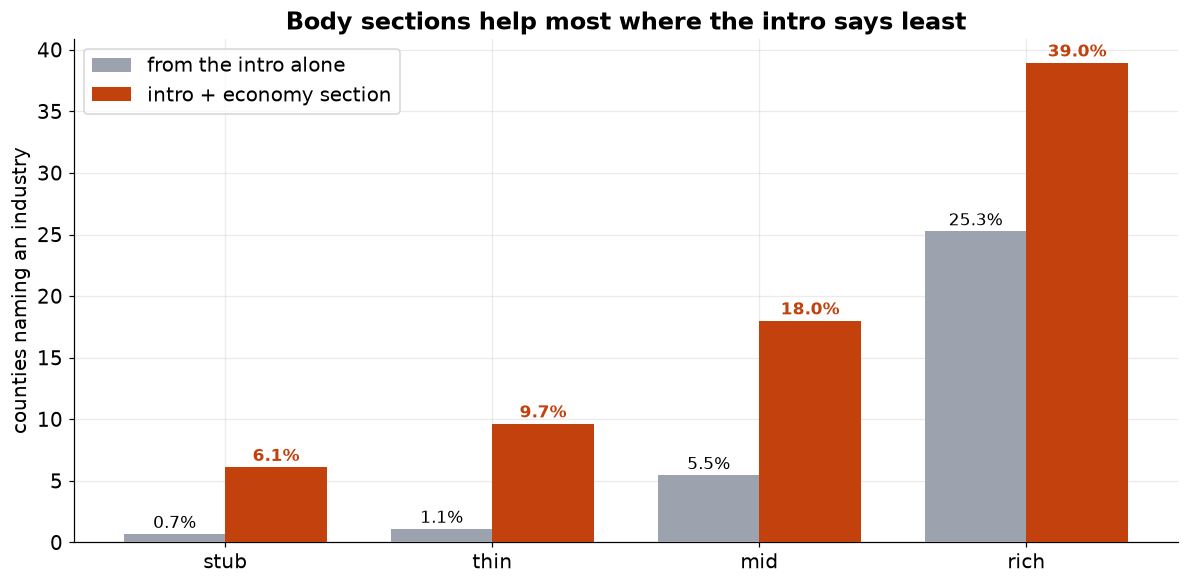

corpus-wide industry coverage: 8.2% -> 18.8% (+332 counties)


In [6]:
by_tier = pd.DataFrame(sec_stats["by_tier"]).T.loc[TIERS]

fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(TIERS)); w = 0.38
ax.bar(x - w/2, by_tier["share_intro_industry"] * 100, w, label="from the intro alone",
       color=MUTED, zorder=3)
ax.bar(x + w/2, (by_tier["share_intro_industry"] + by_tier["share_industry_added"]) * 100, w,
       label="intro + economy section", color=ACCENT, zorder=3)
for i in range(len(TIERS)):
    base = by_tier["share_intro_industry"].iloc[i] * 100
    tot = base + by_tier["share_industry_added"].iloc[i] * 100
    ax.text(i - w/2, base + 0.5, f"{base:.1f}%", ha="center", fontsize=11)
    ax.text(i + w/2, tot + 0.5, f"{tot:.1f}%", ha="center", fontsize=11,
            fontweight="bold", color=ACCENT)
ax.set_xticks(x); ax.set_xticklabels(TIERS)
ax.set_ylabel("counties naming an industry")
ax.set_title("Body sections help most where the intro says least")
ax.legend()
plt.tight_layout(); plt.show()

print(f"corpus-wide industry coverage: {sec_stats['share_intro_industry']:.1%} -> "
      f"{sec_stats['share_intro_industry'] + sec_stats['share_industry_added']:.1%} "
      f"(+{sec_stats['n_industry_added']} counties)")

The **thin tier gains roughly 8× relative to its own near-zero base** — counties
whose opening paragraph is two sentences of population figures but which do have
an Economy section. That is the opposite of the intuition that rich counties
justify deeper reading, and the intro-only framing could not see it.

## 5. Result: 29 readable columns beat 1,024 opaque ones

Every variant is scored identically: 28 targets drawn from the other five
pillars, an unpenalized county-size-plus-state baseline, each representation
fitted to that baseline's residuals, ridge penalty chosen by nested
crossvalidation, seed 42, 5 folds.

In [7]:
order = ["length", "extracted_min", "extracted_mid", "extracted_full",
         "extracted_sections", "sections_x_tier", "pca50", "full"]
labels = {
    "length": "content_length\n(1 col, incumbent)",
    "extracted_min": "typed, minimal\n(4 cols)",
    "extracted_mid": "typed, mid\n(8 cols)",
    "extracted_full": "typed, intro only\n(20 cols)",
    "extracted_sections": "typed + economy section\n(29 cols)",
    "sections_x_tier": "typed x tier\n(120 cols)",
    "pca50": "bge-m3 PCA-50\n(50 cols)",
    "full": "bge-m3 full\n(1024 cols)",
}
table = pd.DataFrame([{
    "variant": labels[k].replace("\n", " "),
    "mean lift": stats["variants"][k]["mean_lift"],
    "raw R2 alone": stats["variants"][k]["mean_r2_alone"],
    "beats incumbent": f"{stats['variants'][k]['n_wins_vs_incumbent']}/{stats['n_targets']}",
    "Wilcoxon p": stats["variants"][k]["wilcoxon_p"],
} for k in order]).set_index("variant")
display(table.style.format({"mean lift": "{:+.5f}", "raw R2 alone": "{:.4f}",
                            "Wilcoxon p": "{:.3f}"}, na_rep="—")
        .set_caption("Every representation, same protocol"))

,mean lift,raw R2 alone,beats incumbent,Wilcoxon p
variant,,,,
"content_length (1 col, incumbent)",+0.00117,0.0198,0/28,—
"typed, minimal (4 cols)",+0.00254,0.0424,13/28,0.493
"typed, mid (8 cols)",+0.00243,0.0420,19/28,0.066
"typed, intro only (20 cols)",+0.00263,0.0444,16/28,0.339
typed + economy section (29 cols),+0.00320,0.0477,19/28,0.081
typed x tier (120 cols),+0.00265,0.0418,19/28,0.066
bge-m3 PCA-50 (50 cols),+0.00171,0.0850,13/28,0.678
bge-m3 full (1024 cols),+0.00273,0.1122,19/28,0.014


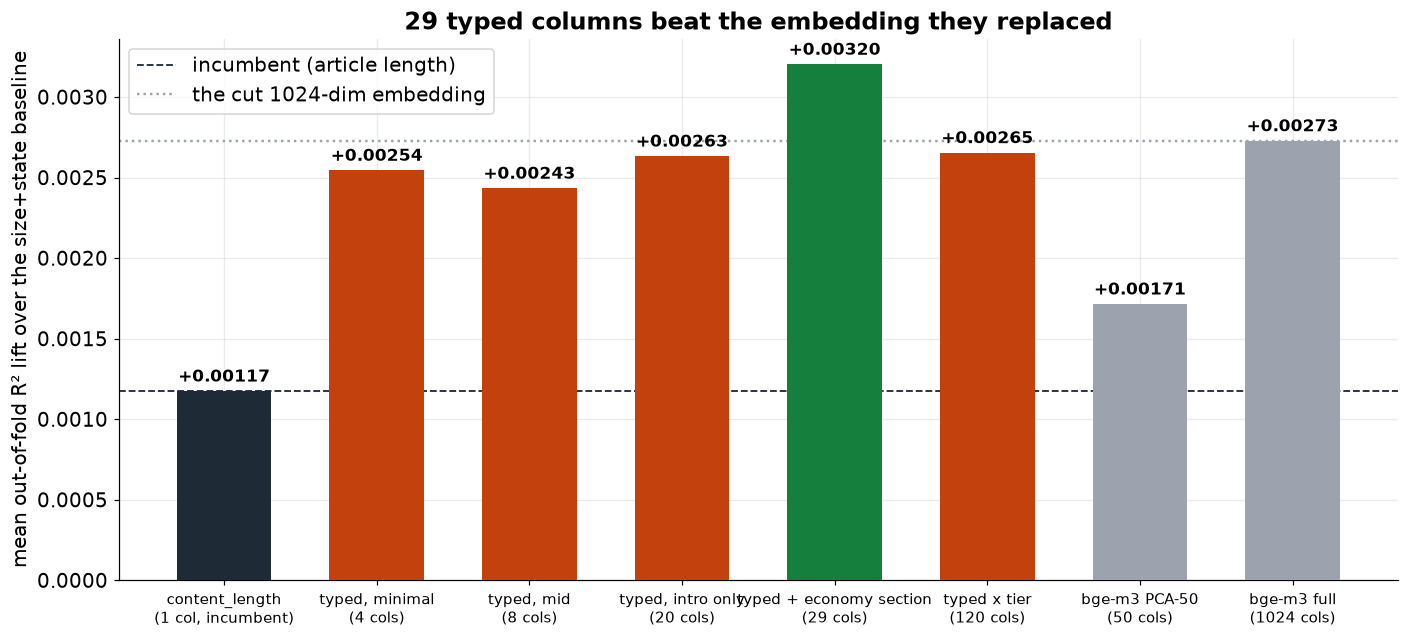

In [8]:
vals = [stats["variants"][k]["mean_lift"] for k in order]
colors = []
for k in order:
    if k == "extracted_sections":
        colors.append(GOOD)
    elif k.startswith("extracted") or k == "sections_x_tier":
        colors.append(ACCENT)
    elif k == "length":
        colors.append(INK)
    else:
        colors.append(MUTED)

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(range(len(order)), vals, color=colors, width=0.62, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + 0.00006, f"{v:+.5f}", ha="center", fontsize=11, fontweight="bold")
ax.axhline(stats["variants"]["length"]["mean_lift"], color=INK, ls="--", lw=1.2,
           label="incumbent (article length)")
ax.axhline(stats["variants"]["full"]["mean_lift"], color=MUTED, ls=":", lw=1.6,
           label="the cut 1024-dim embedding")
ax.set_xticks(range(len(order)))
ax.set_xticklabels([labels[k] for k in order], fontsize=10)
ax.set_ylabel("mean out-of-fold R² lift over the size+state baseline")
ax.set_title("29 typed columns beat the embedding they replaced")
ax.legend(loc="upper left")
plt.tight_layout(); plt.show()

**`extracted_sections` reaches +0.00320** against the incumbent scalar's +0.00117
(2.7×) and the cut embedding's +0.00273 — with 29 columns a person can read, and
no 2.2GB download.

**The honest caveat, which does not go away.** The paired Wilcoxon test is
p = 0.082, short of the usual 0.05. The extraction variants win *large* on a
handful of targets and roughly tie on the rest; the embedding wins *smaller* but
on more of them. Extraction is the better and far cheaper representation on
average — it is **not** uniformly better target by target, and that claim should
not be made.

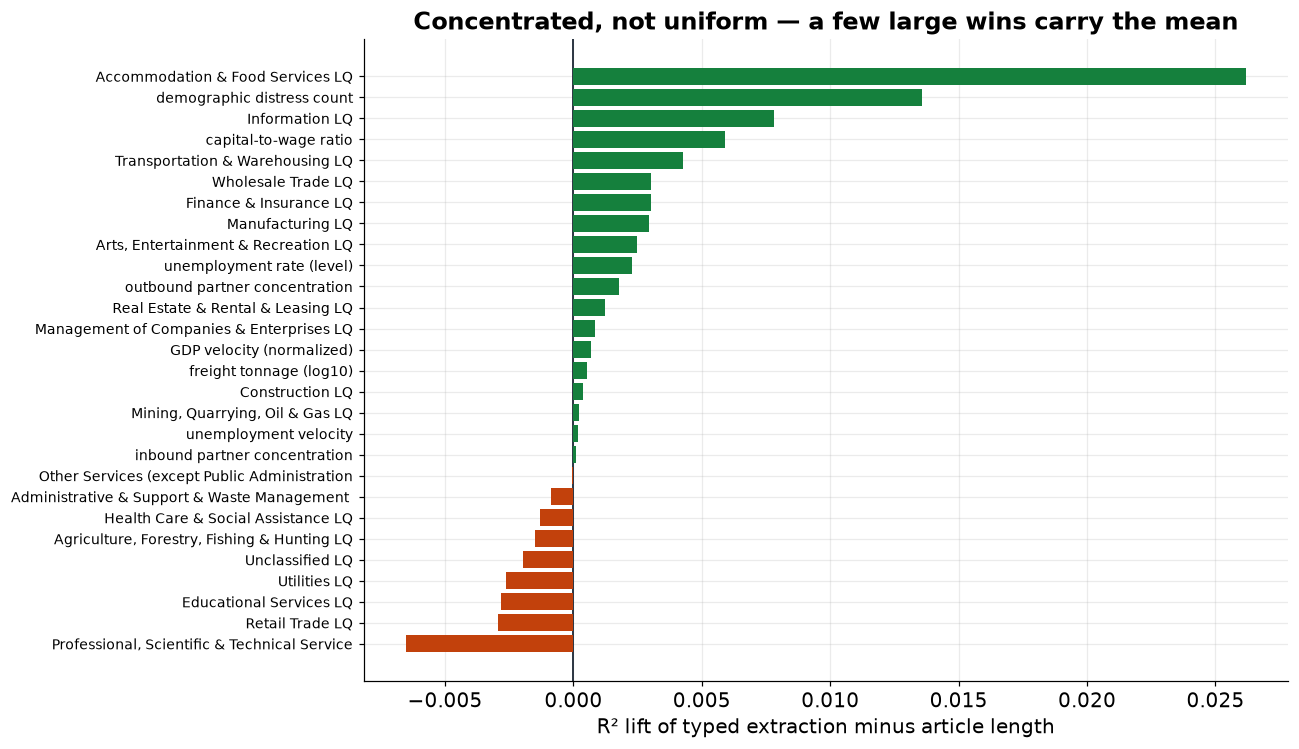

mean difference   +0.00203
median difference +0.00061   <- why the rank-based test stays short of 0.05


In [9]:
diff = (rep["lift_extracted_sections"] - rep["lift_length"]).sort_values()
fig, ax = plt.subplots(figsize=(12, 7))
lbl = rep.loc[diff.index, "label"].str.slice(0, 44)
ax.barh(range(len(diff)), diff.values,
        color=[GOOD if v > 0 else ACCENT for v in diff.values], zorder=3)
ax.set_yticks(range(len(diff))); ax.set_yticklabels(lbl, fontsize=9)
ax.axvline(0, color=INK, lw=1.2)
ax.set_xlabel("R² lift of typed extraction minus article length")
ax.set_title("Concentrated, not uniform — a few large wins carry the mean")
plt.tight_layout(); plt.show()

print(f"mean difference   {diff.mean():+.5f}")
print(f"median difference {diff.median():+.5f}   <- why the rank-based test stays short of 0.05")

## 6. Are the wins real, or curve-fitting?

> **In plain terms:** if the features mean what they say, a county whose article
> mentions resorts and skiing should actually have more hotel and restaurant jobs.

It does.

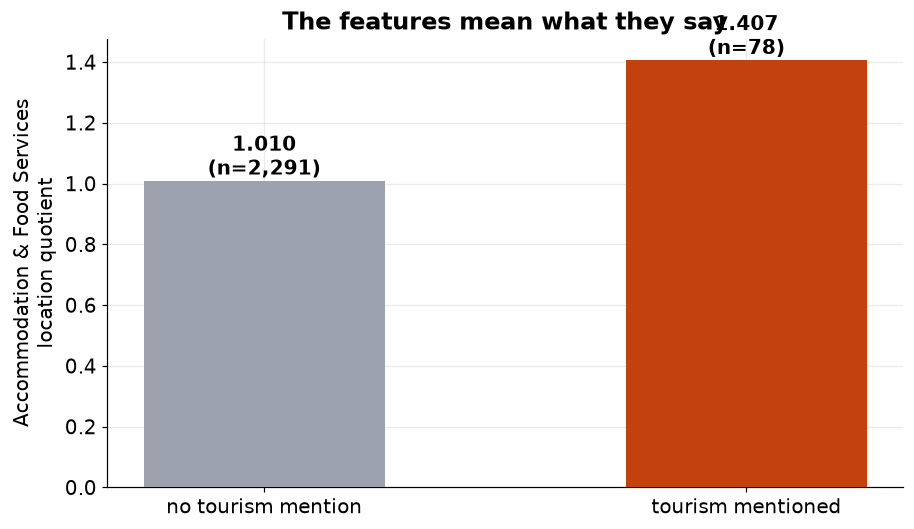

correlation: r = 0.157


In [10]:
sys.path.insert(0, str(REPO / "scripts"))
from pillar_matrix import build_matrix

matrix, blocks = build_matrix()
check = matrix[["has_tourism", "lq_emp_72"]].dropna()
grouped = check.groupby("has_tourism")["lq_emp_72"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.bar(["no tourism mention", "tourism mentioned"], grouped["mean"],
       color=[MUTED, ACCENT], width=0.5, zorder=3)
for i, (m_, n_) in enumerate(zip(grouped["mean"], grouped["count"])):
    ax.text(i, m_ + 0.02, f"{m_:.3f}\n(n={n_:,})", ha="center", fontweight="bold")
ax.set_ylabel("Accommodation & Food Services\nlocation quotient")
ax.set_title("The features mean what they say")
plt.tight_layout(); plt.show()

print(f"correlation: r = {check.has_tourism.corr(check.lq_emp_72):.3f}")

Counties whose article mentions resorts, skiing, or casinos average **1.41** on
tourism-sector employment against **1.01** for those that do not. The single
largest target gain in the whole sweep is this same sector — the mechanism is
visible, not inferred.

## 7. Gains land where the content is

The tiers were never shipped as a feature — tier membership tracks county size,
and whether size is a control or part of the target is still an open question for
this project. They are used to break results out.

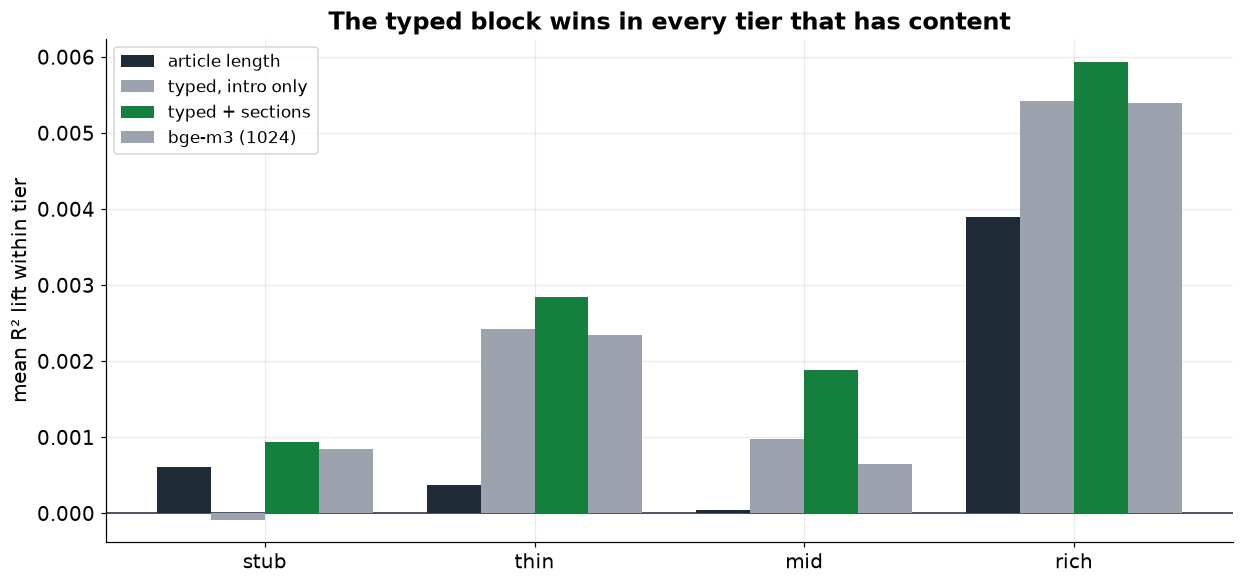

tier,stub,thin,mid,rich
article length,+0.00061,+0.00037,+0.00005,+0.00390
"typed, intro only",-0.00008,+0.00242,+0.00098,+0.00542
typed + sections,+0.00094,+0.00285,+0.00188,+0.00594
bge-m3 (1024),+0.00085,+0.00235,+0.00065,+0.00539


In [11]:
pivot = (rep_tier.groupby(["variant", "tier"])["lift"].mean().unstack()[TIERS]
         .loc[["length", "extracted_full", "extracted_sections", "full"]])
pivot.index = ["article length", "typed, intro only", "typed + sections", "bge-m3 (1024)"]

fig, ax = plt.subplots(figsize=(11.5, 5.5))
x = np.arange(len(TIERS)); w = 0.2
for i, (name, row) in enumerate(pivot.iterrows()):
    c = GOOD if name == "typed + sections" else (INK if name == "article length" else MUTED)
    ax.bar(x + (i - 1.5) * w, row.values, w, label=name, color=c, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(TIERS)
ax.axhline(0, color=INK, lw=1)
ax.set_ylabel("mean R² lift within tier")
ax.set_title("The typed block wins in every tier that has content")
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()
display(pivot.style.format("{:+.5f}"))

Adding sections turns the stub tier from slightly negative to slightly positive,
roughly doubles the mid tier, and gains most in the rich tier — beating the
1,024-dimension embedding in all three tiers that have any content at all.

## 8. Should the tiers branch the model? No.

> **In plain terms:** the original idea was to split counties into groups and
> handle each group differently. The tiers were used to decide *what to extract*,
> but every county still runs through one model. Does letting the groups have
> their own model help?

Tested both ways. Both lose, and the loss scales with how much branching there is.

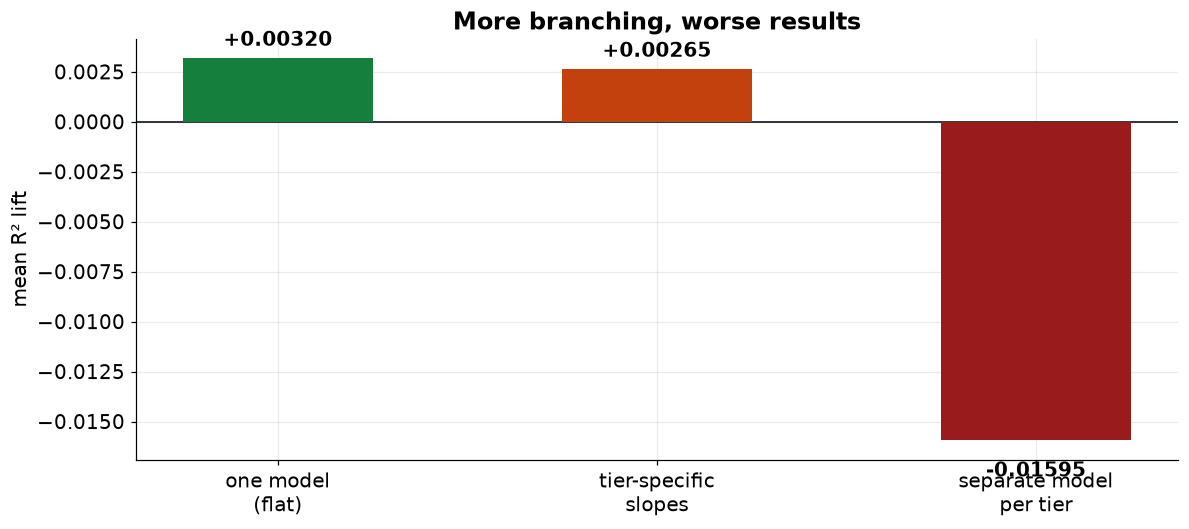

,width,mean lift
approach,,
"one model, one coefficient per feature",29 cols,+0.00320
"one model, coefficients vary by tier",120 cols,+0.00265
"four independent models, one per tier",29 cols x 4 fits,-0.01595


In [12]:
branching = pd.DataFrame([
    {"approach": "one model, one coefficient per feature", "width": "29 cols",
     "mean lift": stats["variants"]["extracted_sections"]["mean_lift"]},
    {"approach": "one model, coefficients vary by tier", "width": "120 cols",
     "mean lift": stats["variants"]["sections_x_tier"]["mean_lift"]},
    {"approach": "four independent models, one per tier", "width": "29 cols x 4 fits",
     "mean lift": -0.01595},
]).set_index("approach")

fig, ax = plt.subplots(figsize=(11, 5))
c = [GOOD, ACCENT, "#991b1b"]
ax.bar(range(3), branching["mean lift"], color=c, width=0.5, zorder=3)
for i, v in enumerate(branching["mean lift"]):
    ax.text(i, v + (0.0006 if v > 0 else -0.0018), f"{v:+.5f}", ha="center", fontweight="bold")
ax.set_xticks(range(3))
ax.set_xticklabels(["one model\n(flat)", "tier-specific\nslopes", "separate model\nper tier"])
ax.axhline(0, color=INK, lw=1.2)
ax.set_ylabel("mean R² lift")
ax.set_title("More branching, worse results")
plt.tight_layout(); plt.show()
display(branching.style.format({"mean lift": "{:+.5f}"}))

Tier-specific slopes cost 17% of the lift. Fully separate per-tier models go
**negative** — worse than dropping Source A entirely — because each trains on
roughly a quarter of the rows and overfits, with no shared penalty to restrain it.

**This is easy to read backwards, so stated carefully:** the tier structure is
real and it mattered. The 23× industry gradient is what identified industry as
the feature family worth building, and the per-tier yield is what justified
refetching article bodies. The tiers were the right **diagnostic**. They are not
the right **architecture** — heterogeneity is better handled by features that are
simply absent when a county has nothing to say, since sparsity already encodes the
tier and the model has more data to learn from when it is not partitioned.

## 9. What ships, and what to watch

**Recommended configuration:** `extracted_sections` — 29 interpretable columns,
one uniform schema across all 3,144 counties, absence encoded as `False` so a
consumer can tell "no university" from "unknown".

| | |
|---|---|
| vs. incumbent `content_length` | **2.7×** mean lift |
| vs. the cut 1024-dim embedding | **1.17×**, at 1/35th the width |
| model download required | none |
| coverage | 3,144 / 3,144 counties, 0 failures |

**Three things not to overstate:**

1. **p = 0.082.** Better on average, not uniformly better. If the bar is "reliably
   better across the board", this does not clear it.
2. **One feature was a size proxy in disguise.** `n_body_sections` correlates with
   county size at r = 0.550 — above `content_length`'s 0.359 — but removing it
   costs only 0.00008 of the 0.00057 section gain. It ships as a diagnostic, not
   a feature.
3. **The refetch pulled live Wikipedia three weeks newer**, so figures moved
   slightly against the earlier run. The embedding's +0.00273 comes from a frozen
   July parquet, so it is a valid reference point but is measured against
   marginally different text than the extraction variants.

**Reproduction** — seed 42 throughout:

```bash
uv run --env-file .env python scripts/ingest_source_a.py
uv run python scripts/extract_source_a_features.py
uv run python scripts/extract_source_a_section_features.py
uv run python scripts/analyze_source_a_tiers.py
uv run python scripts/analyze_source_a_representation.py
```